# Tasks 6 & 7: Feature Selection and Predictive Model

This notebook defines the features for predicting total piece travel time, trains an XGBoost Regressor, and evaluates its performance.

### The prediction problem

**Goal**: Predict the total travel time to the quench bath (`lifetime_bath_s`) using only data available **early in the process** — before the piece has finished the line.

**Why this is useful**: If we can predict the total time after only the 2nd strike, we can raise real-time alerts for pieces that are likely to be slow, allowing operators to investigate the cause while the piece is still on the line.

### Feature selection rationale

**Constraint**: the model must predict using only information available **after the 2nd strike** — approximately 18 seconds into the ~58-second journey. Any feature that requires waiting for later stages cannot be used, because by the time those values exist, the prediction is no longer useful.

#### Selected features

| Feature | Type | Available at | Why include it |
|---|---|---|---|
| `die_matrix` | Categorical (int) | Before processing | Each die has different tooling geometry and expected times — matrix 4974 has a median bath time of ~56s while 5091 has ~59s |
| `lifetime_2nd_strike_s` | Continuous (seconds) | After 2nd strike (~18s) | The earliest cumulative time — if the piece is already slow here, it will likely carry that delay through to the bath |
| `oee_cycle_time_s` | Continuous (seconds) | Rolling metric | Production rate context — slower OEE may correlate with systematic delays (robot trajectory adjustments, hydraulic pressure drops) |

#### Excluded features

| Feature | Why excluded |
|---|---|
| `lifetime_3rd_strike_s` | Available too late (~25s) — the piece is already halfway through the main press |
| `lifetime_4th_strike_s` | Available too late (~38s) — and has ~16% missing data from a sensor offline period |
| `lifetime_auxiliary_press_s` | Available too late (~55s) — only ~2s before the bath, prediction would be useless |
| `lifetime_general_s` | Equivalent to `lifetime_bath_s` — redundant with the target |
| `partial_*` columns | Derived from cumulative times that include late-stage data |
| `piece_id` | Not predictive — just an identifier |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

GOLD_PATH = Path('../data/gold/pieces.parquet')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

FEATURES = ['die_matrix', 'lifetime_2nd_strike_s', 'oee_cycle_time_s']
TARGET = 'lifetime_bath_s'

print("Ready!")

Ready!


## 1. Load gold dataset

In [2]:
# 1. Load gold dataset
df = pd.read_parquet(GOLD_PATH)
print(f"Loaded {len(df):,} pieces")
print(f"Columns: {list(df.columns)}")

Loaded 168,059 pieces
Columns: ['timestamp', 'piece_id', 'die_matrix', 'lifetime_2nd_strike_s', 'lifetime_3rd_strike_s', 'lifetime_4th_strike_s', 'lifetime_bath_s', 'lifetime_general_s', 'processed_at', 'oee_cycle_time_s', 'lifetime_auxiliary_press_s', 'partial_furnace_to_2nd_strike_s', 'partial_2nd_to_3rd_strike_s', 'partial_3rd_to_4th_strike_s', 'partial_4th_strike_to_auxiliary_press_s', 'partial_auxiliary_press_to_bath_s', 'production_run_id']


## 2. Prepare features and target

- **Features (X)**: `die_matrix`, `lifetime_2nd_strike_s`, `oee_cycle_time_s`
- **Target (y)**: `lifetime_bath_s`

Drop rows where any feature or the target is NULL (missing drill data does not affect us here since we don't use drill as a feature).

In [3]:
# 2. Prepare features and target
df_model = df[FEATURES + [TARGET]].dropna()

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Total pieces after dropping NULLs: {len(df_model):,}")
print(f"Dropped: {len(df) - len(df_model):,} rows with missing values")
print(f"\nFeatures:\n{X.describe().round(2)}")

Total pieces after dropping NULLs: 129,160
Dropped: 38,899 rows with missing values

Features:
       die_matrix  lifetime_2nd_strike_s  oee_cycle_time_s
count   129160.00              129160.00         129160.00
mean      5073.65                  18.57             13.87
std         36.16                   2.15              0.58
min       4974.00                   9.80             11.00
25%       5090.00                  16.90             13.47
50%       5090.00                  18.00             13.81
75%       5091.00                  19.80             14.21
max       5091.00                  30.50             16.00


## 3. Feature correlation with target

How strongly does each feature correlate with the total bath time? High correlation suggests predictive value.

In [4]:
# 3. Feature correlation with target
correlations = X.corrwith(y).round(4)
print("Pearson correlation with lifetime_bath_s:")
for feature, corr in correlations.items():
    print(f"  {feature}: {corr}")

Pearson correlation with lifetime_bath_s:
  die_matrix: 0.2432
  lifetime_2nd_strike_s: 0.8136
  oee_cycle_time_s: 0.4477


## 4. Train/test split

Split 80/20 with a fixed random seed for reproducibility. Stratify by die_matrix to ensure each matrix is represented proportionally in both sets.

In [5]:
# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=X['die_matrix']
)

print(f"Training set: {len(X_train):,} pieces")
print(f"Test set:     {len(X_test):,} pieces")
print(f"\nMatrix distribution in training set:")
print(X_train['die_matrix'].value_counts().sort_index())

Training set: 103,328 pieces
Test set:     25,832 pieces

Matrix distribution in training set:
die_matrix
4974    10757
5052    12427
5090    49969
5091    30175
Name: count, dtype: int64


## 5. Train XGBoost Regressor

XGBoost is chosen because:
- Handles mixed feature types (categorical die_matrix + continuous times)
- Robust to the remaining noise in the data
- Fast training on ~100k rows
- Produces feature importance rankings

In [6]:
# 5. Train XGBoost Regressor
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


## 6. Evaluate on test set

Key metrics:
- **RMSE**: root mean squared error (same unit as target — seconds)
- **MAE**: mean absolute error (average prediction error in seconds)
- **R²**: coefficient of determination (1.0 = perfect, 0.0 = no better than mean)

In [7]:
# 6. Evaluate on test set
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("MODEL EVALUATION ON TEST SET")
print("=" * 40)
print(f"RMSE: {rmse:.3f}s")
print(f"MAE:  {mae:.3f}s")
print(f"R²:   {r2:.4f}")
print(f"\nOn a typical bath time of ~58s:")
print(f"Average error: ±{mae:.2f}s ({mae/58*100:.1f}%)")

MODEL EVALUATION ON TEST SET
RMSE: 1.327s
MAE:  0.649s
R²:   0.7855

On a typical bath time of ~58s:
Average error: ±0.65s (1.1%)


## 7. Performance per die matrix

Check if the model performs equally well across all matrices, or if some are harder to predict.

In [8]:
# 7. Performance per die matrix
print("Performance per die matrix:")
print("-" * 50)

X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = y_pred

for matrix in sorted(X_test_copy['die_matrix'].unique()):
    group = X_test_copy[X_test_copy['die_matrix'] == matrix]
    rmse_m = np.sqrt(mean_squared_error(group['y_true'], group['y_pred']))
    mae_m = mean_absolute_error(group['y_true'], group['y_pred'])
    r2_m = r2_score(group['y_true'], group['y_pred'])
    print(f"Matrix {matrix}: RMSE={rmse_m:.3f}s  MAE={mae_m:.3f}s  R²={r2_m:.4f}  (n={len(group):,})")

Performance per die matrix:
--------------------------------------------------
Matrix 4974: RMSE=1.070s  MAE=0.502s  R²=0.6927  (n=2,689)
Matrix 5052: RMSE=0.948s  MAE=0.444s  R²=0.8401  (n=3,107)
Matrix 5090: RMSE=1.587s  MAE=0.830s  R²=0.6981  (n=12,492)
Matrix 5091: RMSE=1.038s  MAE=0.484s  R²=0.8724  (n=7,544)


## 8. Feature importance

Which features contribute most to the prediction? This validates the feature selection rationale.

,feature,importance
1,lifetime_2nd_strike_s,0.659667
2,oee_cycle_time_s,0.277544
0,die_matrix,0.062789


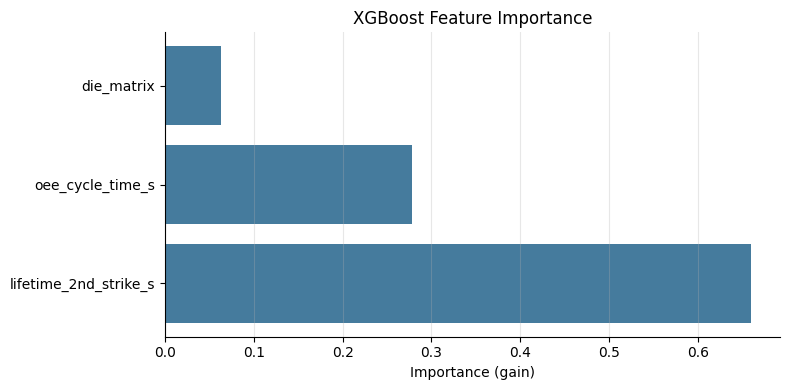

In [9]:
# 8. Feature importance
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance['feature'], importance['importance'], color='#457b9d')
ax.set_xlabel('Importance (gain)')
ax.set_title('XGBoost Feature Importance')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Save model and metadata

Save the trained model and its metadata for use by the inference service (Task 8).

In [10]:
# 9. Save model and metadata
model.get_booster().save_model(str(MODELS_DIR / 'xgboost_bath_predictor.json'))

metadata = {
    'features': FEATURES,
    'target': TARGET,
    'metrics': {
        'rmse': round(rmse, 4),
        'mae': round(mae, 4),
        'r2': round(r2, 4)
    },
    'hyperparameters': {
        'n_estimators': 200,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    },
    'die_matrices': sorted([int(m) for m in df['die_matrix'].unique()]),
    'oee_median': round(float(df['oee_cycle_time_s'].median()), 2)
}

with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model saved to models/xgboost_bath_predictor.json")
print("Metadata saved to models/model_metadata.json")
print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))

Model saved to models/xgboost_bath_predictor.json
Metadata saved to models/model_metadata.json

Metadata:
{
  "features": [
    "die_matrix",
    "lifetime_2nd_strike_s",
    "oee_cycle_time_s"
  ],
  "target": "lifetime_bath_s",
  "metrics": {
    "rmse": 1.3268,
    "mae": 0.6486,
    "r2": 0.7855
  },
  "hyperparameters": {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8
  },
  "die_matrices": [
    4974,
    5052,
    5090,
    5091
  ],
  "oee_median": 13.81
}


## 10. Summary

In [11]:
# 10. Summary
print("=" * 50)
print("FEATURE SELECTION & MODEL SUMMARY")
print("=" * 50)

print("\n PREDICTION PROBLEM")
print("  Predict lifetime_bath_s after only the 2nd strike")
print("  (~18s into a ~58s process)")

print("\n SELECTED FEATURES")
for f in FEATURES:
    print(f"  - {f}")

print("\n EXCLUDED FEATURES")
excluded = ['lifetime_3rd_strike_s', 'lifetime_4th_strike_s', 
            'lifetime_auxiliary_press_s', 'lifetime_general_s', 'partial_* columns']
for f in excluded:
    print(f"  - {f}")

print("\n MODEL PERFORMANCE")
print(f"  RMSE: {rmse:.3f}s")
print(f"  MAE:  {mae:.3f}s")
print(f"  R²:   {r2:.4f}")

print("\n FEATURE IMPORTANCE")
for _, row in importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("\n SAVED ARTIFACTS")
print("  models/xgboost_bath_predictor.json")
print("  models/model_metadata.json")
print("=" * 50)

FEATURE SELECTION & MODEL SUMMARY

 PREDICTION PROBLEM
  Predict lifetime_bath_s after only the 2nd strike
  (~18s into a ~58s process)

 SELECTED FEATURES
  - die_matrix
  - lifetime_2nd_strike_s
  - oee_cycle_time_s

 EXCLUDED FEATURES
  - lifetime_3rd_strike_s
  - lifetime_4th_strike_s
  - lifetime_auxiliary_press_s
  - lifetime_general_s
  - partial_* columns

 MODEL PERFORMANCE
  RMSE: 1.327s
  MAE:  0.649s
  R²:   0.7855

 FEATURE IMPORTANCE
  lifetime_2nd_strike_s: 0.6597
  oee_cycle_time_s: 0.2775
  die_matrix: 0.0628

 SAVED ARTIFACTS
  models/xgboost_bath_predictor.json
  models/model_metadata.json
